# corgi-howfsc Loop Outputs Analysis

This notebook is for poking around the outputs of a `corgi-howfsc` HOWFSC loop run,
so that I can connect the file structure (see the [Loop outputs docs](https://roman-corgi.github.io/corgihowfsc/loop_outputs.html))
back to the theory in Cady et al. 2025

Rough map from paper concepts -> files:

| Paper concept | Section | Files |
|---|---|---|
| Pairwise probing / probe images | Sec. 2.2 | `images.fits` |
| Probe-based E-field estimation ($\hat E_0$), bad-pixel flagging | Sec. 2.3-2.4 | `efield_estimations.fits` |
| Model / "perfect" E-field | Sec. 3.2 | `perfect_efields.fits` |
| Coherent / incoherent intensity split ($I_{coh}$, $I_{inc}$) | Sec. 2.2, Eq. 9 | `intensity_coherent.fits`, `intensity_incoherent.fits`, `intensity_total.fits` |
| Electric Field Conjugation (EFC) solve, Jacobian, regularization | Sec. 3.1, Eq. 26-27 | `svd_snorm.fits`, `svd_iri.fits`, `dm1_command.fits`, `dm2_command.fits` |
| Control strategy / per-pixel weights | Sec. 4.1 | `config.yml`, `debugging_history.csv` |
| Loop convergence / measured vs. predicted contrast | Sec. 3-4 | `measured_contrast.csv`, `predicted_contrast.csv`, `contrast_vs_iteration.pdf` |


In [2]:
## Configuration 
# top-level output directory of a HOWFSC loop run, i.e. the
# folder that directly contains config.yml etc.

from pathlib import Path

# LOOP_DIR = Path("/Users/Zahra1/corgiloop_data/corgi-howfsc_gitl/2026-07-09_131630_compact_model") 
# LOOP_DIR = Path("C:/Users/zahmed1/corgiloop_data/corgi-howfsc_gitl/2026-07-15_101842_compact_model")
LOOP_DIR = Path("C:/Users/zahmed1/corgiloop_data/corgi-howfsc_gitl/2026-07-22_000322_compact_model")
print(f"Using output directory: {LOOP_DIR.resolve()}")


Using output directory: C:\Users\zahmed1\corgiloop_data\corgi-howfsc_gitl\2026-07-22_000322_compact_model


In [3]:
## Imports 
import os
import re
import glob
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from astropy.io import fits
import yaml

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["image.origin"] = "lower"

In [4]:
## Helper functions (copying over from PHYSICS260 notebooks)

def list_iterations(loop_dir):
    '''Return sorted list of (iteration_number, Path) for all iteration_XXXX folders.'''
    dirs = sorted(glob.glob(str(loop_dir / "iteration_*")))
    out = []
    for d in dirs:
        m = re.search(r"iteration_(\d+)$", d)
        if m:
            out.append((int(m.group(1)), Path(d)))
    return out


def iter_dir(loop_dir, iteration):
    '''Path to a specific iteration_XXXX folder, given an integer iteration number.'''
    candidates = list(loop_dir.glob(f"iteration_{iteration:04d}"))
    if not candidates:
        raise FileNotFoundError(f"No iteration_{iteration:04d} folder found under {loop_dir}")
    return candidates[0]

def load_csv(path, verbose=True):
    path = Path(path)
    if not path.exists():
        if verbose:
            print(f"[missing] {path}")
        return None
    df = pd.read_csv(path)
    if verbose:
        print(f"[loaded]  {path.name:<32s} shape={df.shape}")
    return df


def show_grid(cube, titles=None, suptitle=None, cmap="inferno", log=False, ncols=None, figsize_per=3.2):
    '''Plot each plane of a 3D array (or a single 2D array) in a grid of imshow panels.'''
    if cube is None:
        print("Nothing to plot (data is None).")
        return
    if cube.ndim == 2:
        arr = cube[np.newaxis, ...]
    else:
        arr = cube
    n = arr.shape[0]
    ncols = ncols or min(n, 4)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per * ncols, figsize_per * nrows), squeeze=False)
    for i in range(nrows * ncols):
        ax = axes[i // ncols][i % ncols]
        if i < n:
            frame = arr[i]
            if log:
                pos = frame[frame > 0]
                vmin = np.percentile(pos, 1) if pos.size else 1e-12
                vmax = np.percentile(pos, 99.9) if pos.size else 1.0
                norm = mcolors.LogNorm(vmin=max(vmin, 1e-12), vmax=max(vmax, vmin * 10))
                im = ax.imshow(frame, cmap=cmap, norm=norm)
            else:
                im = ax.imshow(frame, cmap=cmap)
            ax.set_title(titles[i] if titles else f"plane {i}", fontsize=10)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()


AVAILABLE_ITERATIONS = list_iterations(LOOP_DIR)
print(f"Found {len(AVAILABLE_ITERATIONS)} iteration folder(s): "
      f"{[n for n, _ in AVAILABLE_ITERATIONS[:5]]}{' ...' if len(AVAILABLE_ITERATIONS) > 5 else ''}")


Found 40 iteration folder(s): [1, 2, 3, 4, 5] ...


## 1. Top-level pre-loop outputs

Before the loop starts, `corgi-howfsc` writes `config.yml` (all input parameters), `gitl.log`
(runtime log), and optionally `image_worker_debug.csv` / `gitl_rank<rank>.log` if debug mode /
MPI were enabled.

In [5]:
config_path = LOOP_DIR / "config.yml"

with open(config_path) as f:
    config = yaml.safe_load(f)
# Pretty-print the top level keys/values; drill into `config` directly for nested settings.
for k, v in config.items():
    print(f"{k}: {v}")
else:
    if config_path.exists():
        print(config_path.read_text())
    else:
        print(f"[missing] {config_path}")


_meta: {'timestamp': '20260722_000324', 'command': 'C:\\Users\\zahmed1\\Documents\\corgihowfsc/corgihowfsc/scripts/run_corgisim_nulling_gitl.py', 'fileout': 'C:\\Users\\zahmed1\\corgiloop_data\\corgi-howfsc_gitl\\2026-07-22_000322_compact_model\\final_frames.fits'}
active_model: cgi-howfsc
backend_type: cgi-howfsc
normalization_type: eetc
niter: 40
mode: wfov_band4
dark_hole: 360deg
probe_shape: default
precomp: precomp_jacs_always
num_process: 15
num_threads: 1
num_imager_worker: 3
num_proper_process: 5
use_mpi: False
crop_params: {'nrow': 153, 'ncol': 153, 'lrow': 436, 'lcol': 436}
corgi_overrides: {'output_dim': 153, 'NCPUS': 5}
fileout: C:\Users\zahmed1\corgiloop_data\corgi-howfsc_gitl\2026-07-22_000322_compact_model\final_frames.fits
jacpath: C:\Users\zahmed1\Documents\corgihowfsc\temp
inputs: {'modelpath': 'C:\\Users\\zahmed1\\Documents\\corgihowfsc\\corgihowfsc\\model\\wfov_band4\\wfov_band4_360deg', 'cfgfile': 'C:\\Users\\zahmed1\\Documents\\corgihowfsc\\corgihowfsc\\model\\wfo

In [ ]:
# log_path = LOOP_DIR / "gitl.log"

# if log_path.exists():
#     lines = log_path.read_text().splitlines()
#     print(f"gitl.log has {len(lines)} lines. Showing first 40:\n")
#     print("\n".join(lines[:]))
# else:
#     print(f"[missing] {log_path}")


In [ ]:
# debug_csv_path = LOOP_DIR / "image_worker_debug.csv"
# image_worker_debug = load_csv(debug_csv_path)
# if image_worker_debug is not None:
#     display(image_worker_debug.head())


### Getting the per-wavelength pixels per lambda/D at the detector!

In [6]:
model_yaml_path = Path(config["inputs"]["cfgfile"])
with open(model_yaml_path) as f:
    optical_model = yaml.safe_load(f)

ppl_per_lam = [optical_model["sls"][i]["fs"]["ppl"] for i in sorted(optical_model["sls"])]
lam_per_lam = [optical_model["sls"][i]["lam"] for i in sorted(optical_model["sls"])]  # meters
print(ppl_per_lam)
print([f"{lam * 1e9:.1f} nm" for lam in lam_per_lam])

[3.1382097356516145, 3.26574179194932, 3.3936693617116385]
['791.4 nm', '823.6 nm', '855.8 nm']


## 2. Per Iteration Outputs

In [7]:
ITERATION = 1

ITER_DIR = iter_dir(LOOP_DIR, ITERATION)
print(f"Inspecting iteration {ITERATION}: {ITER_DIR}")
print("Contents:", sorted(p.name for p in ITER_DIR.iterdir()))

Inspecting iteration 1: C:\Users\zahmed1\corgiloop_data\corgi-howfsc_gitl\2026-07-22_000322_compact_model\iteration_0001
Contents: ['dm1_command.fits', 'dm2_command.fits', 'efield_estimations.fits', 'images.fits', 'intensity_coherent.fits', 'intensity_incoherent.fits', 'intensity_total.fits', 'perfect_efields.fits', 'svd_iri.fits', 'svd_snorm.fits']


## 2a. Probe images (`images.fits`)

Per Cady et al. Sec. 2.2, CGI estimates the coherent E-field at each pixel using **pairwise probing**: an
unprobed image $I_0$, plus a $+/-$ image pair for each of `nprobepair` DM probes, repeated at
each of `nlam` wavelengths. So `images.fits` has `nlam * ndm` planes, where
`ndm = 1 + 2 * nprobepair` (Eq. 9-11 describe $I_0$, $I_+$, $I_-$ for a single probe/wavelength).

In [8]:
iter_images = (ITER_DIR / "images.fits")

hdul = fits.open(iter_images)
print(hdul.info())

Filename: C:\Users\zahmed1\corgiloop_data\corgi-howfsc_gitl\2026-07-22_000322_compact_model\iteration_0001\images.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  RAW_IMAGES    1 ImageHDU         9   (153, 153, 21)   float64   
  2  CAM_PARAMS    1 ImageHDU         7   (21,)   float64   
None


In [9]:
# CAM_PARAMS is the per-plane EXCAM exposure time (seconds), one value per RAW_IMAGES
# plane.
#   - nulling_gitl.py: dm1_list/dm2_list are built wavelength-major:
#       for each wavelength: [unprobed, probe1(+), probe1(-), probe2(+), probe2(-), ...]
#   - saving_output.py: camlist[i] = [gain_list, exptime_list, nframes_list] per iteration;
#       only exptime_list is written out as CAM_PARAMS (gain/nframes are not saved here).
raw_images = hdul["RAW_IMAGES"].data
cam_params = hdul["CAM_PARAMS"].data
print("CAM_PARAMS (exposure time, sec, one per RAW_IMAGES plane):\n", cam_params)

CAM_PARAMS (exposure time, sec, one per RAW_IMAGES plane):
 [3.37700989 1.37844198 1.37844198 1.37844198 1.37844198 1.37844198
 1.37844198 4.85909803 1.88630337 1.88630337 1.88630337 1.88630337
 1.88630337 1.88630337 6.71026921 2.52162792 2.52162792 2.52162792
 2.52162792 2.52162792 2.52162792]


In [10]:
def load_probe_images(path, nprobepair=len(config["inputs"]["probefiles"])):
    with fits.open(path) as hdul:
        raw = hdul["RAW_IMAGES"].data
    ndm = 1 + 2 * nprobepair
    nlam = raw.shape[0] // ndm
    return raw.reshape(nlam, ndm, *raw.shape[1:])


def show_probe_images(cube, wavelength_index, ppl_per_lam, cmap="inferno", crop_lod=None):
    ndm = cube.shape[1]
    nprobepair = (ndm - 1) // 2
    frames = cube[wavelength_index]
    titles = ["unprobed (I_0)"]
    for p in range(nprobepair):
        titles += [f"probe {p + 1} (+)", f"probe {p + 1} (-)"]

    ny, nx = frames.shape[1:]
    ppl = ppl_per_lam[wavelength_index]
    extent = [-(nx // 2) / ppl, (nx // 2) / ppl, -(ny // 2) / ppl, (ny // 2) / ppl]  # Converting pixels to Lambda/D
    xlim = (-crop_lod, crop_lod) if crop_lod else (extent[0], extent[1]) # Don't need to show outside the OWA so will just crop it out
    ylim = (-crop_lod, crop_lod) if crop_lod else (extent[2], extent[3])

    fig, axes = plt.subplots(1, ndm, figsize=(3.2 * ndm, 3.2))
    for ax, frame, title in zip(axes, frames, titles):
        vmin, vmax = np.percentile(frame, [1, 99.9])
        im = ax.imshow(frame, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(r"x [$\lambda/D$]")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[0].set_ylabel(r"y [$\lambda/D$]")
    fig.suptitle(f"images.fits - iteration {ITERATION}, wavelength {wavelength_index}")
    fig.tight_layout()
    plt.show()

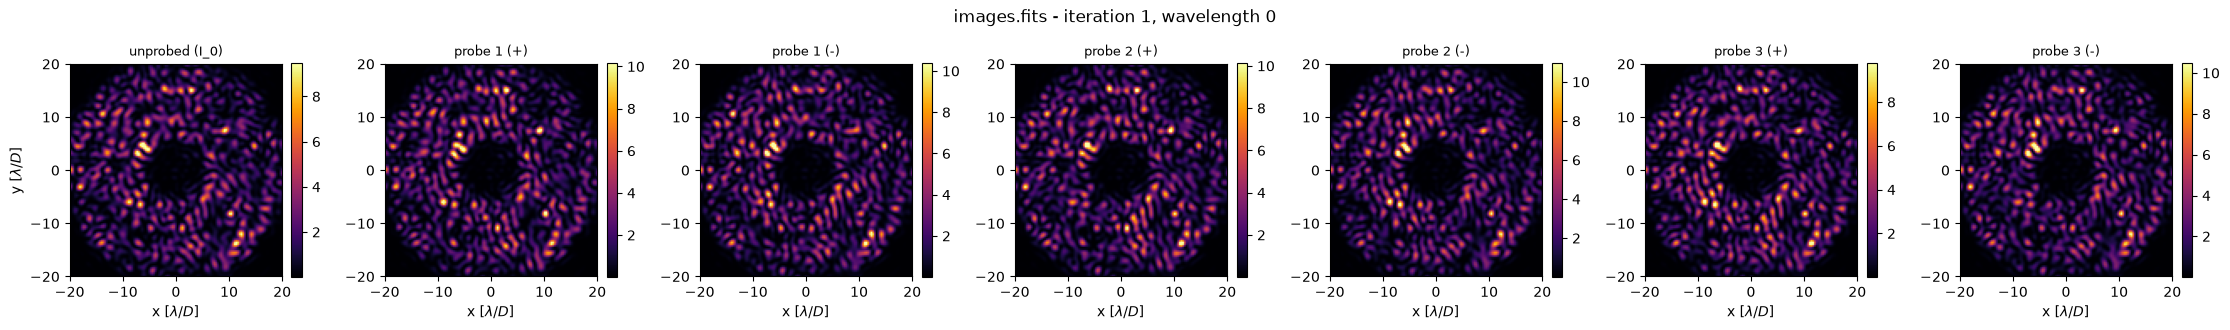

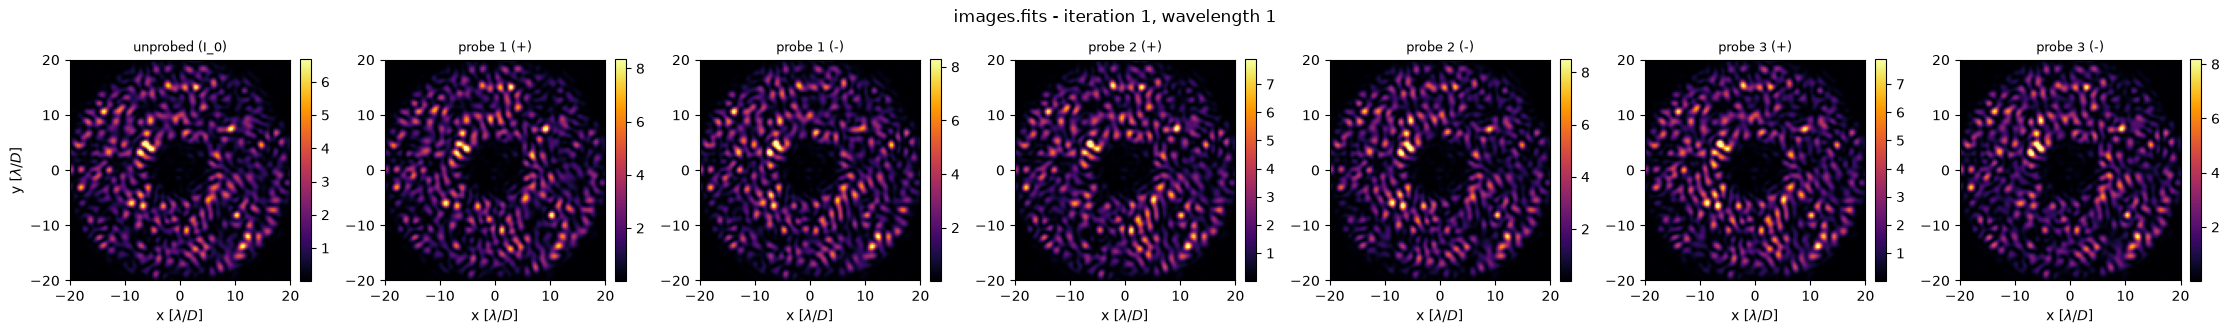

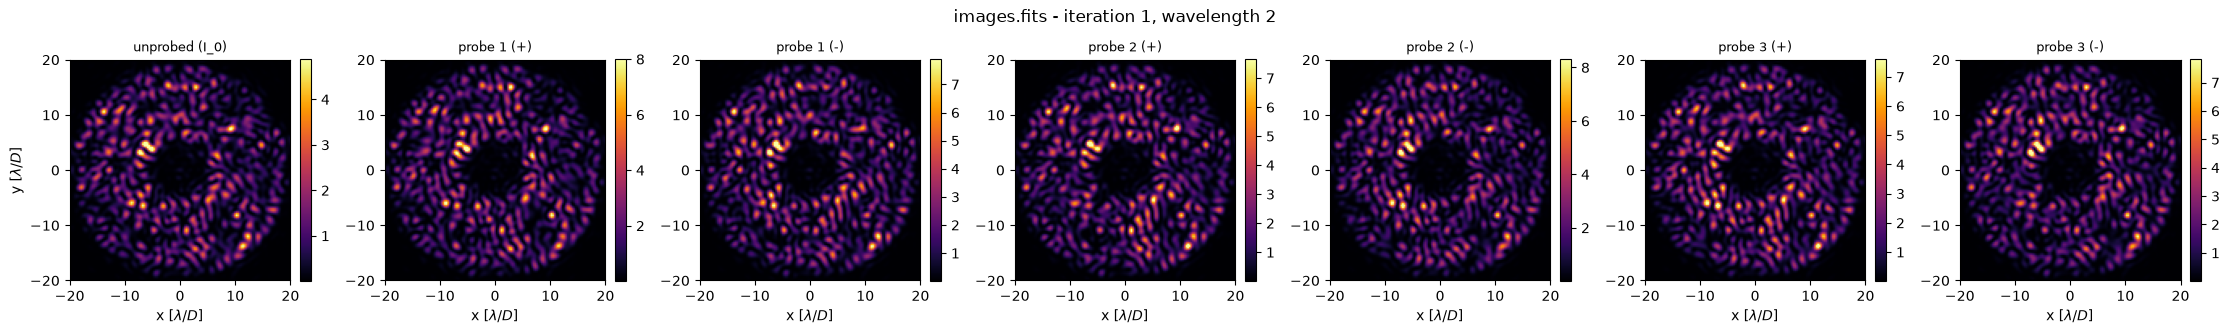

In [11]:
probe_cube = load_probe_images(iter_images)

for lam in range(probe_cube.shape[0]):
    show_probe_images(probe_cube, lam, ppl_per_lam, crop_lod=20.0)


### Notes:
* Focal plane images above are in units of counts

### Now instead of in units of counts convert back to normalized intensity 

In [12]:
debugging_history = load_csv(LOOP_DIR / "debugging_history.csv")

[loaded]  debugging_history.csv            shape=(120, 17)


In [13]:
debugging_history = load_csv(LOOP_DIR / "debugging_history.csv")
peakflux_per_lam = (
    debugging_history[debugging_history["iteration"] == ITERATION]
    .sort_values("lam_index")["peakflux"]
    .to_numpy()
)

exptime_cube = cam_params.reshape(probe_cube.shape[0], probe_cube.shape[1])  # (nlam, ndm)
contrast_cube = probe_cube / (peakflux_per_lam[:, None, None, None] * exptime_cube[:, :, None, None])


[loaded]  debugging_history.csv            shape=(120, 17)


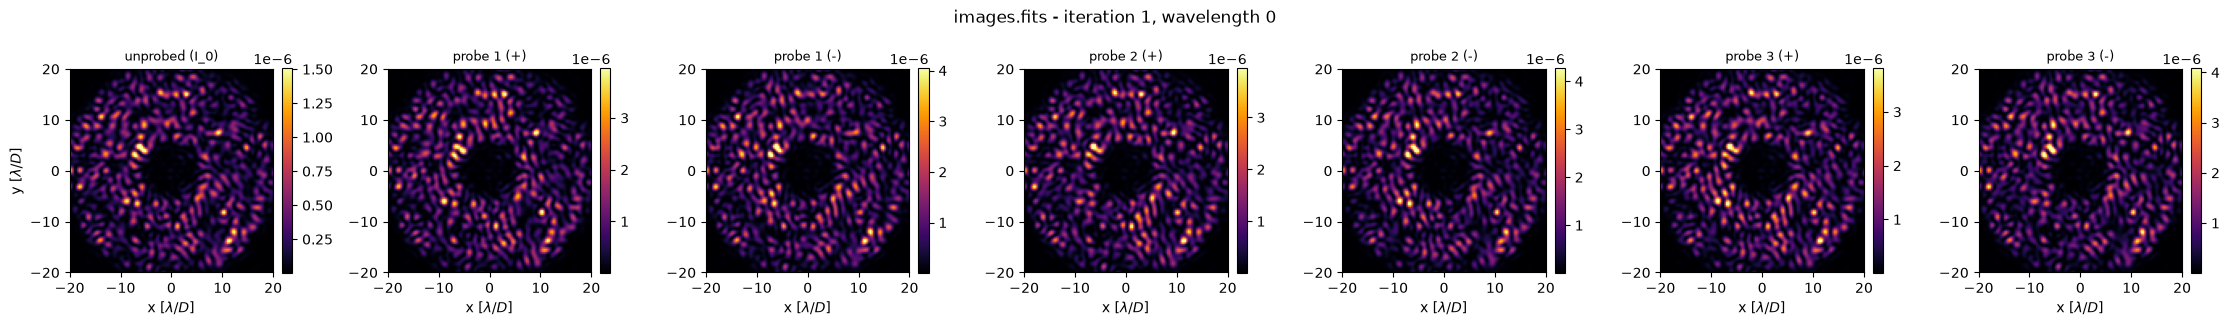

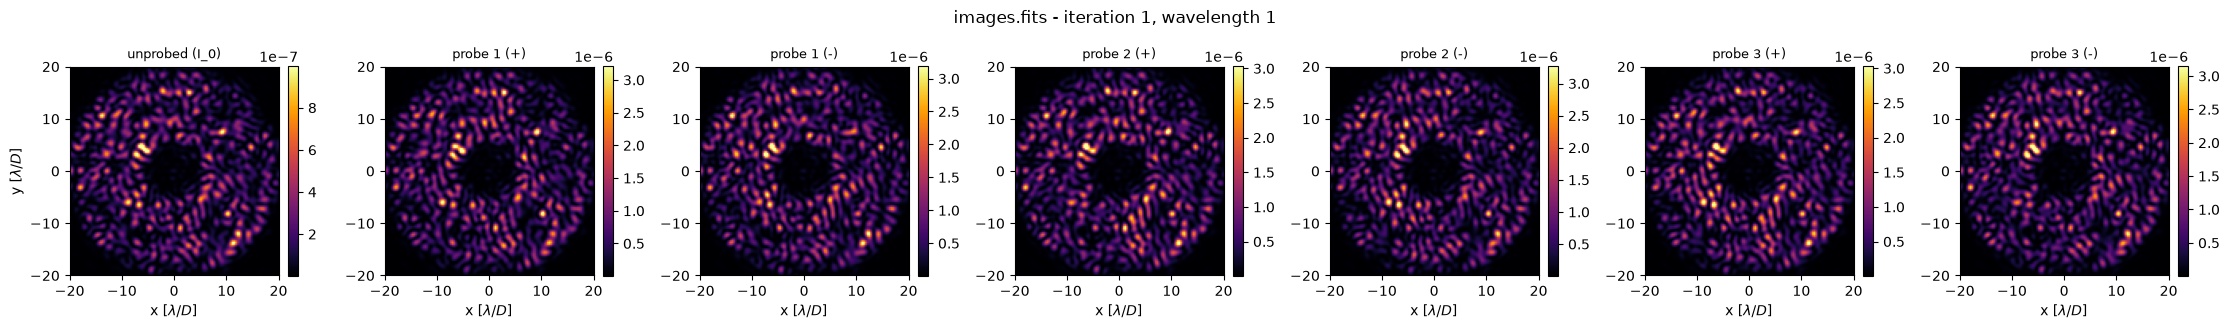

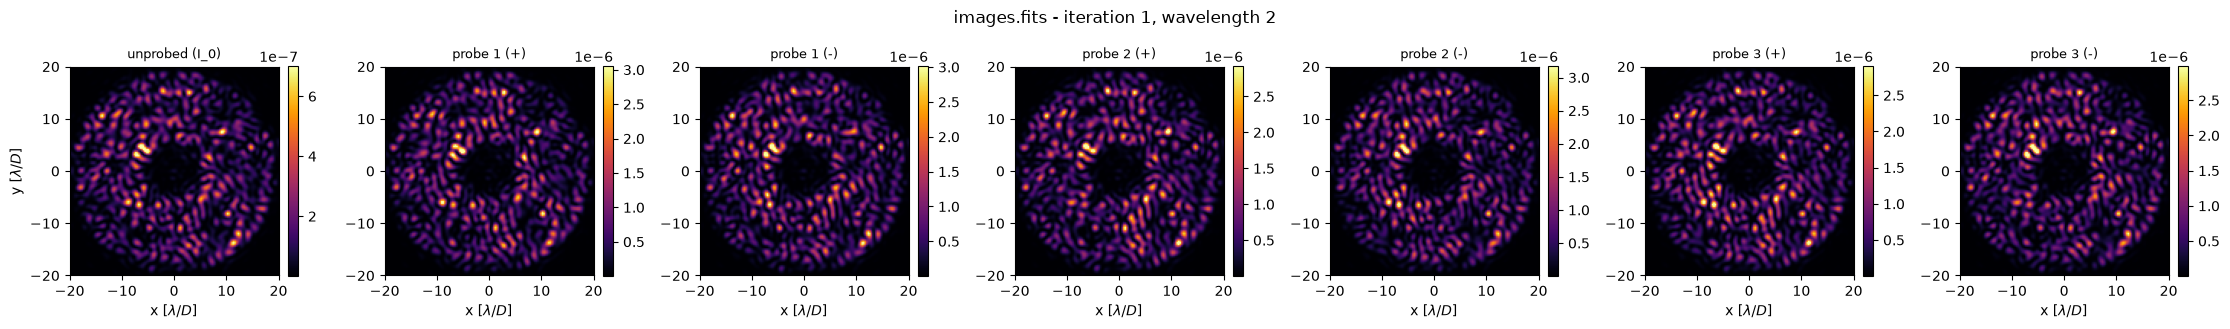

In [14]:
for lam in range(contrast_cube.shape[0]):
    show_probe_images(contrast_cube, lam, ppl_per_lam, crop_lod=20.0)

## 2b. Coherent / incoherent / total intensity

Eq. 9 splits the measured intensity into a **coherent** term $I_{coh} = |C[E_0]|^2$ (the part
that interferes with starlight and is correctable by the DMs) and an **incoherent** term
$I_{inc}$ (astrophysical signal, stray light, etc., which DM probing cannot modulate). Each cube
has `nlam` frames, one per wavelength.

In [ ]:
intensity_total, _ = load_fits(ITER_DIR / "intensity_total.fits")
intensity_coherent, _ = load_fits(ITER_DIR / "intensity_coherent.fits")
intensity_incoherent, _ = load_fits(ITER_DIR / "intensity_incoherent.fits")

for name, cube in [("total", intensity_total), ("coherent", intensity_coherent), ("incoherent", intensity_incoherent)]:
    if cube is not None:
        nlam = cube.shape[0]
        show_grid(cube, titles=[f"{name} - lambda {i}" for i in range(nlam)],
                   suptitle=f"intensity_{name}.fits - iteration {ITERATION}", log=True)


In [ ]:
# Side-by-side comparison at a single wavelength
WAVELENGTH_INDEX = 0   

cubes = {"total": intensity_total, "coherent": intensity_coherent, "incoherent": intensity_incoherent}
available = {k: v for k, v in cubes.items() if v is not None}

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4.5))
    if len(available) == 1:
        axes = [axes]
    for ax, (name, cube) in zip(axes, available.items()):
        frame = cube[WAVELENGTH_INDEX]
        pos = frame[frame > 0]
        norm = mcolors.LogNorm(vmin=np.percentile(pos, 1), vmax=np.percentile(pos, 99.9)) if pos.size else None
        im = ax.imshow(frame, cmap="inferno", norm=norm)
        ax.set_title(f"{name} intensity, lambda {WAVELENGTH_INDEX}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Iteration {ITERATION}")
    fig.tight_layout()
    plt.show()


## 2c. Estimated vs. model ("perfect") E-field

`efield_estimations.fits` is the **measured** electric field $\hat E_0$ produced by the pairwise
probing estimator (Sec. 2.2-2.4). `perfect_efields.fits` is the electric field predicted by the
HOWFSC **optical model** for the same DM setting (used e.g. to build the Jacobian, Sec. 3.2-3.3).
Comparing the two is a good way to gauge model mismatch (the paper notes this directly: model
mismatch issues can be investigated by comparing the complex-valued correlation between the
change in the measured and modeled electric fields between iterations). Both cubes are stored as
interleaved real/imaginary planes: `R-W1, I-W1, R-W2, I-W2, ...` for `nlam` wavelengths
(`2 * nlam` planes total).

In [ ]:
efield_hdul = fits.open(ITER_DIR / "efield_estimations.fits")
efield_est = efield_hdul[1].data
perf_hdul  = fits.open(ITER_DIR / "perfect_efields.fits")
perfect_efield = perf_hdul[1].data

def planes_to_complex(cube):
    '''Cube with interleaved [R-W1, I-W1, R-W2, I-W2, ...] planes -> complex array (nlam, ny, nx).'''
    if cube is None:
        return None
    real = cube[0::2]
    imag = cube[1::2]
    return real + 1j * imag


E_est = planes_to_complex(efield_est)
E_model = planes_to_complex(perfect_efield)

if E_est is not None:
    print(f"Estimated E-field: {E_est.shape[0]} wavelength(s), frame shape {E_est.shape[1:]}")
if E_model is not None:
    print(f"Model E-field:     {E_model.shape[0]} wavelength(s), frame shape {E_model.shape[1:]}")


In [ ]:
WAVELENGTH_INDEX = 0   # <-- EDIT ME

if E_est is not None:
    field = E_est[WAVELENGTH_INDEX]
    amp = np.abs(field)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    pos = amp[amp > 0]
    norm = mcolors.LogNorm(vmin=np.percentile(pos, 1), vmax=np.percentile(pos, 99.9)) if pos.size else None
    im0 = axes[0].imshow(amp, cmap="inferno", norm=norm)
    axes[0].set_title(f"|E_est|, lambda {WAVELENGTH_INDEX}")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(np.angle(field), cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[1].set_title(f"phase(E_est), lambda {WAVELENGTH_INDEX}")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"Estimated E-field - iteration {ITERATION}")
    fig.tight_layout()
    plt.show()


In [ ]:
# Estimated vs. model E-field amplitude, and their difference - a quick look at model mismatch
if E_est is not None and E_model is not None:
    est_amp = np.abs(E_est[WAVELENGTH_INDEX])
    model_amp = np.abs(E_model[WAVELENGTH_INDEX])
    diff = est_amp - model_amp

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, data, title, cmap in zip(
        axes, [est_amp, model_amp, diff],
        ["|E_est|", "|E_model|", "|E_est| - |E_model|"],
        ["inferno", "inferno", "RdBu_r"],
    ):
        if cmap == "RdBu_r":
            vmax = np.nanpercentile(np.abs(data), 99)
            im = ax.imshow(data, cmap=cmap, vmin=-vmax, vmax=vmax)
        else:
            pos = data[data > 0]
            norm = mcolors.LogNorm(vmin=np.percentile(pos, 1), vmax=np.percentile(pos, 99.9)) if pos.size else None
            im = ax.imshow(data, cmap=cmap, norm=norm)
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Measured vs. model E-field amplitude - iteration {ITERATION}, lambda {WAVELENGTH_INDEX}")
    fig.tight_layout()
    plt.show()

    # Complex correlation coefficient between estimated and model fields (flattened, finite values only)
    a, b = E_est[WAVELENGTH_INDEX].ravel(), E_model[WAVELENGTH_INDEX].ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    corr = np.vdot(a[mask], b[mask]) / (np.linalg.norm(a[mask]) * np.linalg.norm(b[mask]))
    print(f"Complex correlation coefficient (est vs. model), |corr| = {np.abs(corr):.3f}, phase = {np.angle(corr):.3f} rad")


## 2d. DM commands

`dm1_command.fits` / `dm2_command.fits` are the **absolute** DM voltage settings applied for this
iteration - i.e. the result of the previous iteration's EFC solve, $a_0 + \Delta a$ from Eq. 27.

In [ ]:
dm1_hdul = fits.open(ITER_DIR / "dm1_command.fits")
dm1 = dm1_hdul[0].data

In [ ]:
dm1_hdul = fits.open(ITER_DIR / "dm1_command.fits")
dm1 = dm1_hdul[0].data
dm2_hdul = fits.open(ITER_DIR / "dm2_command.fits")
dm2 = dm2_hdul[0].data

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, data, title in zip(axes, [dm1, dm2], ["DM1 command", "DM2 command"]):
    if data is not None:
        im = ax.imshow(data, cmap="viridis")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"{title} - iteration {ITERATION}")
    ax.axis("off")
fig.tight_layout()
plt.show()


## 2e. SVD diagnostics

`svd_snorm.fits` gives the normalized singular values squared of the EFC linear system
($J^T J$, related to Eq. 26-27), and `svd_iri.fits` the power per mode in the same order. These
are useful for sanity-checking the conditioning of the EFC solve / Tikhonov regularization
choices described in the control-strategy discussion (Sec. 4.1).

In [ ]:
svd_snorm_hdul = fits.open(ITER_DIR / "svd_snorm.fits")
svd_snorm = svd_snorm_hdul[0].data
svd_iri_hdul = fits.open(ITER_DIR / "svd_iri.fits")
svd_iri = svd_iri_hdul[0].data

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
if svd_snorm is not None:
    axes[0].semilogy(np.ravel(svd_snorm), ".-")
    axes[0].set_title("svd_snorm.fits (normalized singular values^2)")
    axes[0].set_xlabel("mode index")
    axes[0].grid(alpha=0.3)
if svd_iri is not None:
    axes[1].semilogy(np.ravel(svd_iri), ".-", color="C1")
    axes[1].set_title("svd_iri.fits (power per mode)")
    axes[1].set_xlabel("mode index")
    axes[1].grid(alpha=0.3)
fig.suptitle(f"Iteration {ITERATION}")
fig.tight_layout()
plt.show()


## 3. Post-loop, run-level outputs

Everything below is written once, after the full loop finishes, and summarizes performance
across *all* iterations - this is the quickest way to see whether the loop actually converged
(dark-hole contrast dropping with iteration) and whether the model tracked reality
(measured vs. predicted contrast).

In [ ]:
measured_contrast = load_csv(LOOP_DIR / "measured_contrast.csv")
predicted_contrast = load_csv(LOOP_DIR / "predicted_contrast.csv")

# Add column with row (iteration) number:
iter_num_pred = range(1, len(measured_contrast) + 1)
iter_num_meas = range(len(measured_contrast))
measured_contrast.insert(0, 'iteration', iter_num_meas)
predicted_contrast.insert(0,'iteration', iter_num_pred)
# measured_contrast.index = range(1, len(measured_contrast) + 1)
# measured_contrast.index.name = 'iteration'

if measured_contrast is not None:
    display(measured_contrast.head())
if predicted_contrast is not None:
    display(predicted_contrast.head())


In [ ]:
# Recreate contrast_vs_iteration.pdf from the underlying data
fig, ax = plt.subplots(figsize=(7, 5))
for df, label, style in [(measured_contrast, "measured", "o-"), (predicted_contrast, "predicted", "s--")]:
    if df is not None:
        x_col = "iteration" if "iteration" in df.columns else df.columns[0]
        y_cols = [c for c in df.columns if c != x_col]
        for y_col in y_cols:
            ax.semilogy(df[x_col], df[y_col], style, label=f"{label}: {y_col}")
ax.set_xlabel("iteration")
ax.set_ylabel("contrast")
ax.set_title("Measured vs. predicted contrast")
ax.legend()
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()


## 4. Dark hole images over the iterations 

In [15]:
LAM_INDEX = probe_cube.shape[0] // 2  # central wavelength channel
NDM = probe_cube.shape[1]

def unprobed_contrast(images_path, iteration_number, lam_index=LAM_INDEX):
    with fits.open(images_path) as hdul:
        raw = hdul[1].data.reshape(-1, NDM, *hdul[1].data.shape[1:])
        exptime = hdul[2].data.reshape(-1, NDM)
    peakflux = (
        debugging_history[debugging_history["iteration"] == iteration_number]
        .sort_values("lam_index")["peakflux"]
        .to_numpy()[lam_index]
    )
    return raw[lam_index, 0] / (peakflux * exptime[lam_index, 0])


frames = [unprobed_contrast(d / "images.fits", n) for n, d in AVAILABLE_ITERATIONS]
frames.append(unprobed_contrast(LOOP_DIR / "final_frames.fits", AVAILABLE_ITERATIONS[-1][0]))
labels = [f"iter {n}" for n, _ in AVAILABLE_ITERATIONS] + ["final"]



In [16]:
dh_mask_path = model_yaml_path.parent / optical_model["sls"][LAM_INDEX]["dh"]
with open(dh_mask_path.with_suffix(".yaml")) as f:
    dh_mask_cfg = yaml.safe_load(f)
dh_shape = next(iter(dh_mask_cfg["shapes"].values()))
IWA_LOD, OWA_LOD = dh_shape["radiusInnerLamD"], dh_shape["radiusOuterLamD"]
print(f"Dark-hole mask ({dh_mask_path.parent.name}): IWA={IWA_LOD} lam/D, OWA={OWA_LOD} lam/D")

def radial_mask(shape, ppl, iwa=IWA_LOD, owa=None):
    ny, nx = shape
    y, x = np.mgrid[0:ny, 0:nx]
    r_lod = np.hypot(x - nx // 2, y - ny // 2) / ppl
    mask = r_lod < iwa
    if owa is not None:
        mask |= r_lod > owa
    return mask

ppl = ppl_per_lam[LAM_INDEX]
mask = radial_mask(frames[0].shape, ppl, owa=OWA_LOD)
frames = [np.where(mask, np.nan, f) for f in frames]

Dark-hole mask (subband1): IWA=5.6 lam/D, OWA=20.4 lam/D


In [17]:
np.shape(frames)

(41, 153, 153)

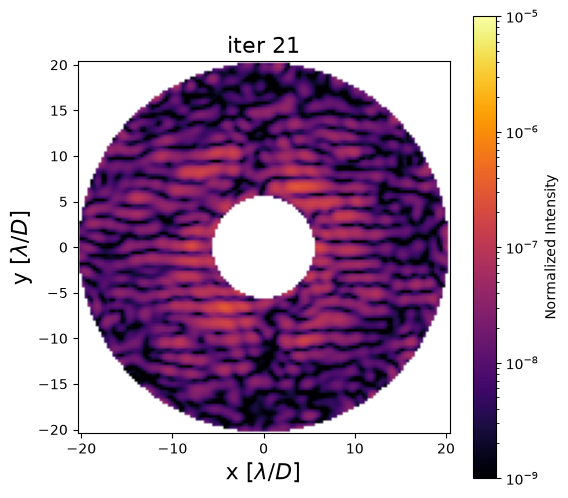

In [43]:
# Single Iteration (log scale)
iterNum = 20
ftsz = 16

ppl = ppl_per_lam[LAM_INDEX]
lam_nm = lam_per_lam[LAM_INDEX] * 1e9
ny, nx = frames[0].shape
extent = [-(nx // 2) / ppl, (nx // 2) / ppl, -(ny // 2) / ppl, (ny // 2) / ppl]  # lambda/D
crop_lod = OWA_LOD

valid = np.concatenate([f.ravel() for f in frames])
valid = valid[np.isfinite(valid) & (valid > 0)]
# vmin, vmax = np.percentile(valid, [1, 99.9])
vmin = 1e-9
vmax = 1e-5
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(6, 6))
frame = frames[iterNum]
label = labels[iterNum]
im = ax.imshow(frame, cmap="inferno", norm=norm, extent=extent)
cbar = fig.colorbar(im, label="Normalized Intensity")
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.set_xlim(-crop_lod, crop_lod)
ax.set_ylim(-crop_lod, crop_lod)
ax.set_title(label, fontsize=ftsz)
ax.set_xlabel(r"x [$\lambda/D$]", fontsize=ftsz)
ax.set_ylabel(r"y [$\lambda/D$]", fontsize=ftsz)
# fig.suptitle(f"Dark hole evolution - {lam_nm:.1f} nm", fontsize=ftsz)
plt.show()

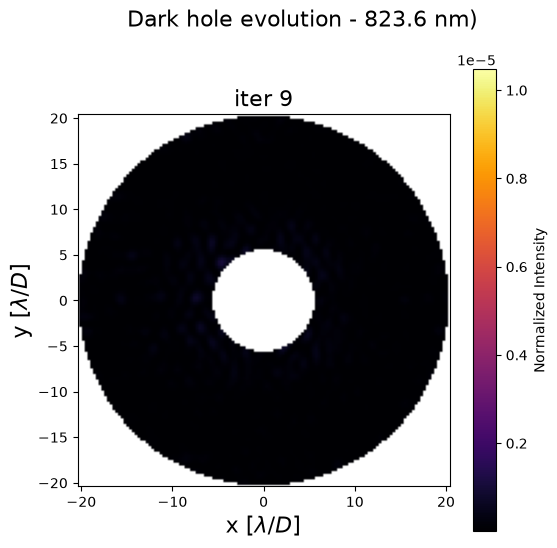

In [35]:
# Single Iteration (linear scale)
iterNum = 8
ftsz = 16

ppl = ppl_per_lam[LAM_INDEX]
lam_nm = lam_per_lam[LAM_INDEX] * 1e9
ny, nx = frames[0].shape
extent = [-(nx // 2) / ppl, (nx // 2) / ppl, -(ny // 2) / ppl, (ny // 2) / ppl]  # lambda/D
crop_lod = OWA_LOD

vmin, vmax = np.nanpercentile(np.concatenate([f.ravel() for f in frames]), [1, 99.9])

fig, ax = plt.subplots(figsize=(6, 6))
frame = frames[iterNum]
label = labels[iterNum]
im = ax.imshow(frame, cmap="inferno", vmin=vmin, vmax=vmax, extent=extent)
fig.colorbar(im, label="Normalized Intensity")
ax.set_xlim(-crop_lod, crop_lod)
ax.set_ylim(-crop_lod, crop_lod)
ax.set_title(label, fontsize=ftsz)
ax.set_xlabel(r"x [$\lambda/D$]", fontsize=ftsz)
ax.set_ylabel(r"y [$\lambda/D$]", fontsize=ftsz)
fig.suptitle(f"Dark hole evolution - {lam_nm:.1f} nm)", fontsize=ftsz)
plt.show()

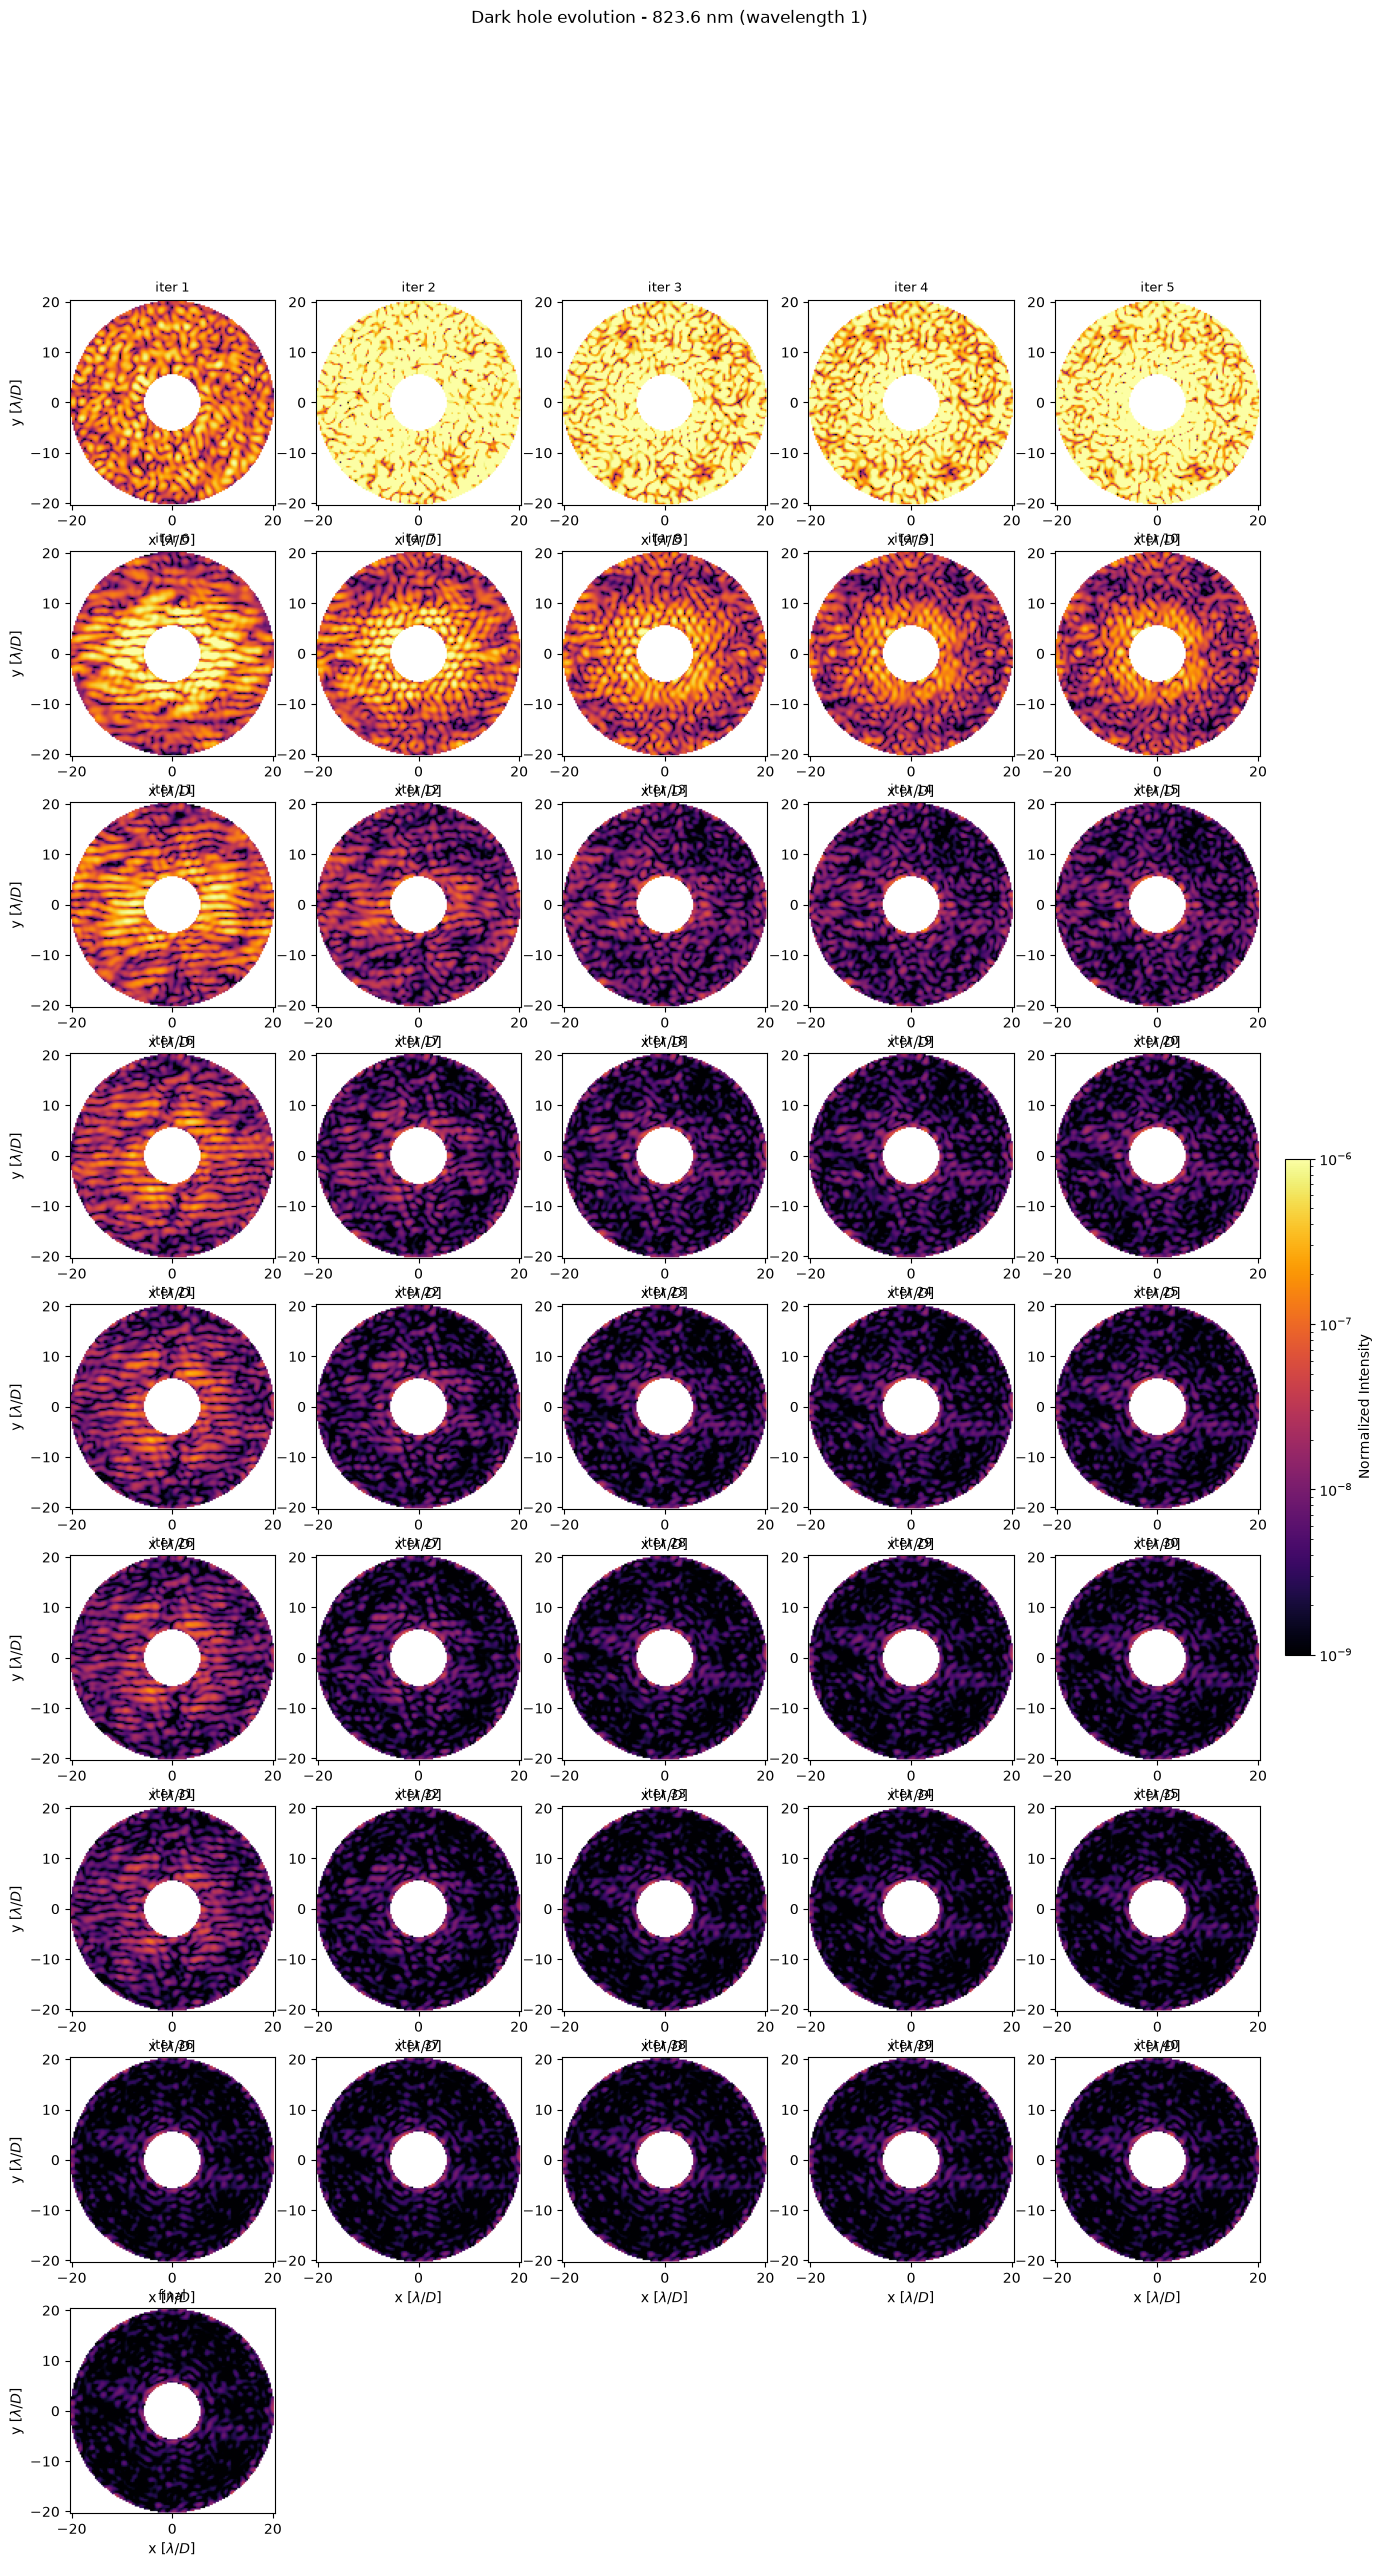

In [28]:
# All frames at once (log scale)

ppl = ppl_per_lam[LAM_INDEX]
lam_nm = lam_per_lam[LAM_INDEX] * 1e9
ny, nx = frames[0].shape
extent = [-(nx // 2) / ppl, (nx // 2) / ppl, -(ny // 2) / ppl, (ny // 2) / ppl]  # lambda/D
crop_lod = OWA_LOD

valid = np.concatenate([f.ravel() for f in frames])
valid = valid[np.isfinite(valid) & (valid > 0)]
# vmin, vmax = np.percentile(valid, [1, 99.9])
vmin = 1e-9
vmax = 1e-6
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

ncols = min(len(frames), 5)
nrows = int(np.ceil(len(frames) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), squeeze=False)
for i in range(nrows * ncols):
    ax = axes[i // ncols][i % ncols]
    if i < len(frames):
        im = ax.imshow(frames[i], cmap="inferno", norm=norm, extent=extent)
        ax.set_xlim(-crop_lod, crop_lod)
        ax.set_ylim(-crop_lod, crop_lod)
        ax.set_title(labels[i], fontsize=9)
        ax.set_xlabel(r"x [$\lambda/D$]")
        if i % ncols == 0:
            ax.set_ylabel(r"y [$\lambda/D$]")
    else:
        ax.axis("off")
cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Normalized Intensity")
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
fig.suptitle(f"Dark hole evolution - {lam_nm:.1f} nm (wavelength {LAM_INDEX})")
plt.show()

In [ ]:
# All frames at once (linear scale)

ppl = ppl_per_lam[LAM_INDEX]
lam_nm = lam_per_lam[LAM_INDEX] * 1e9
ny, nx = frames[0].shape
extent = [-(nx // 2) / ppl, (nx // 2) / ppl, -(ny // 2) / ppl, (ny // 2) / ppl]  # lambda/D
crop_lod = OWA_LOD

vmin, vmax = np.nanpercentile(np.concatenate([f.ravel() for f in frames]), [1, 99.9])

ncols = min(len(frames), 5)
nrows = int(np.ceil(len(frames) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), squeeze=False)
for i in range(nrows * ncols):
    ax = axes[i // ncols][i % ncols]
    if i < len(frames):
        im = ax.imshow(frames[i], cmap="inferno", vmin=vmin, vmax=vmax, extent=extent)
        ax.set_xlim(-crop_lod, crop_lod)
        ax.set_ylim(-crop_lod, crop_lod)
        ax.set_title(labels[i], fontsize=9)
        ax.set_xlabel(r"x [$\lambda/D$]")
        if i % ncols == 0:
            ax.set_ylabel(r"y [$\lambda/D$]")
    else:
        ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Normalized Intensity")
fig.suptitle(f"Dark hole evolution - {lam_nm:.1f} nm (wavelength {LAM_INDEX})")
plt.show()

In [42]:
# GIF of the dark hole evolution (log scale, fixed colorbar)

from matplotlib.animation import FuncAnimation, PillowWriter

ftsz = 16

valid = np.concatenate([f.ravel() for f in frames])
valid = valid[np.isfinite(valid) & (valid > 0)]
# vmin, vmax = np.percentile(valid, [1, 99.9])
vmin = 1e-9
vmax = 1e-5
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(frames[0], cmap="inferno", norm=norm, extent=extent)
ax.set_xlim(-crop_lod, crop_lod)
ax.set_ylim(-crop_lod, crop_lod)
ax.set_xlabel(r"x [$\lambda/D$]", fontsize=ftsz)
ax.set_ylabel(r"y [$\lambda/D$]", fontsize=ftsz)
title = ax.set_title(labels[0], fontsize=ftsz)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="normalized intensity")
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10, labelOnlyBase=True))
cbar.ax.tick_params(labelsize=15)

def update(i):
    im.set_data(frames[i])
    title.set_text(labels[i])
    return im, title

anim = FuncAnimation(fig, update, frames=len(frames), interval=800)
anim.save(LOOP_DIR / "dark_hole_evolution_log.gif", writer=PillowWriter(fps=1.25))
plt.close(fig)

In [31]:
# GIF of the dark hole evolution (linear scale)

from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(frames[0], cmap="inferno", extent=extent)
ax.set_xlim(-crop_lod, crop_lod)
ax.set_ylim(-crop_lod, crop_lod)
ax.set_xlabel(r"x [$\lambda/D$]")
ax.set_ylabel(r"y [$\lambda/D$]")
title = ax.set_title(labels[0])
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="normalized intensity")

def update(i):
    im.set_data(frames[i])
    vmin_i, vmax_i = np.nanpercentile(frames[i], [1, 99.9])
    im.set_clim(vmin_i, vmax_i) 
    title.set_text(labels[i])
    cbar.update_normal(im)
    return im, title

anim = FuncAnimation(fig, update, frames=len(frames), interval=800)
anim.save(LOOP_DIR / "dark_hole_evolution_linear.gif", writer=PillowWriter(fps=1.25))
plt.close(fig)

## Initial DM Solutions (i.e. before the first iteration)

In [ ]:
# dm1_init_fits = Path("C:/Users/zahmed1/Documents/corgihowfsc/corgihowfsc/model/wfov_band4/wfov_band4_360deg/gitl_start_compact_dm1.fits")
# dm2_init_fits = Path("C:/Users/zahmed1/Documents/corgihowfsc/corgihowfsc/model/wfov_band4/wfov_band4_360deg/gitl_start_compact_dm2.fits")
# dm1_init_fits = Path("C:/Users/zahmed1/Documents/corgihowfsc/corgihowfsc/model/wfov_band4/any/dmabs_init_dm1.fits")
# dm2_init_fits = Path("C:/Users/zahmed1/Documents/corgihowfsc/corgihowfsc/model/wfov_band4/any/dmabs_init_dm2.fits")
# dm1_init_fits = Path("C:/Users/zahmed1/Documents/cgisim_cpp/roman_preflight_proper/examples/spc-wide_ni_3e-9_dm1_v.fits") # from PROPER examples
# dm2_init_fits = Path("C:/Users/zahmed1/Documents/cgisim_cpp/roman_preflight_proper/examples/spc-wide_ni_3e-9_dm2_v.fits") # from PROPER examples (see "run_spc_wide.py")
dm1_init_fits = Path("C:/Users/zahmed1/Documents/cgisim_cpp/roman_preflight_proper/examples/spc-wide_flat_wfe_dm1_v.fits")  # from PROPER examples (see "run_spc_wide.py")
dm2_init_fits = Path("C:/Users/zahmed1/Documents/cgisim_cpp/roman_preflight_proper/examples/spc-wide_flat_wfe_dm2_v.fits")  # from PROPER examples (see "run_spc_wide.py")
dm1_hdul = fits.open(dm1_init_fits)
dm2_hdul = fits.open(dm2_init_fits)

In [ ]:
print(dm1_hdul.info())

In [ ]:
dm1 = dm1_hdul[0].data
dm2 = dm2_hdul[0].data

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, data, title in zip(axes, [dm1, dm2], ["DM1 command", "DM2 command"]):
    if data is not None:
        im = ax.imshow(data, cmap="viridis")
        fig.colorbar(im, label="[Volts]")
    ax.set_title(f"{title} - Initial Map")
    ax.axis("off")
fig.tight_layout()
plt.show()

## Code Profiling Plot: Scrape the gitl.log file to extract times for each step

In [ ]:
import re

log_path = LOOP_DIR / "gitl.log"
lines = log_path.read_text().splitlines()

jac_times = []
imaging_times = []
howfsc_times = []
total_times = []

jac_init    = "Initial jac calc time"
frame_init  = "Initial framelist collection time"
jac_iter    = "Jac recalc time"
howfsc_iter = "HOWFSC computation time" 
frame_iter  = "Framelist collection time for iteration"
total_iter  = "Total iteration time for iteration"

target_strings = ["Initial jac calc time", "Initial framelist collection time", "Jac recalc time", "HOWFSC computation time", 
                  "Framelist collection time for iteration", "Total iteration time for iteration"]

results = [line for line in lines for target in target_strings if target in line]

for result in results:

    if total_iter in result or frame_iter in result:
        pattern = r"iteration\s+\d+:\s+([0-9]*\.?[0-9]+)\s+seconds"
        match   = re.search(pattern, result)
        value   = float(match.group(1))
    else:
        temp = result.split("time:")
        temp2 = temp[-1].strip().split()
        value = float(temp2[0])

    if jac_init in result or jac_iter in result:
        jac_times.append(value)
        continue
    if frame_init in result or frame_iter in result:
        imaging_times.append(value)
        continue
    if howfsc_iter in result:
        howfsc_times.append(value)
        continue
    if total_iter in result:
        total_times.append(value)
        continue

In [ ]:
# Recreate contrast_vs_iteration.pdf from the underlying data
fig, ax = plt.subplots(figsize=(12, 5))
if jac_times:
    ax.semilogy(np.arange(0,len(jac_times)), jac_times, "o-", label="Jacobian Calculation")
if imaging_times:
    ax.semilogy(np.arange(0,len(imaging_times)), imaging_times, "*-", label="Imaging Simulation")
if howfsc_times:
    ax.semilogy(np.arange(1,len(howfsc_times)+1), howfsc_times, "s-", label="HOWFSC Loop")
if total_times:
    ax.semilogy(np.arange(1,len(total_times)+1), total_times, "-", label="Total iteration time")
jac_times_padded = jac_times
jac_times_padded.append(0)
added_times = np.array(jac_times_padded[1:]) + np.array(howfsc_times) + np.array(imaging_times[1:])
ax.semilogy(np.arange(1,len(total_times)+1), added_times, "--", label="Jac + Imaging + HOWFSC")
ax.set_xlabel("iteration")
ax.set_ylabel("time [seconds]")
ax.set_xticks(np.arange(0,len(howfsc_times)+1))
ax.set_title("Computation time")
ax.grid(alpha=0.3, which="both")
ax.legend(loc="best")
# fig.tight_layout()
plt.show()
fig.savefig(LOOP_DIR / "computation_time.png")
